# EDA, Cleaning, and Tokenization for Nepali Caption Dataset

This notebook does four things in order:

1. Reads the original dataset
2. Cleans the dataset and saves a cleaned CSV file
3. Performs EDA on the cleaned dataset
4. Trains and compares BPE and WordPiece tokenizers on the cleaned Nepali captions

The markdown notes are written in simple words so they are easy to reuse in an assignment report.

In [1]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer, WordPieceTrainer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("dataset") / "nepali_captions_v1.csv"
CLEANED_DATA_PATH = Path("dataset") / "nepali_captions_v1_cleaned.csv"
TOKENIZER_DIR = Path("tokenizers")
TOKENIZER_DIR.mkdir(exist_ok=True)

base_columns = ["original_text", "video_id", "eng_captions", "nepali_captions"]

raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

,original_text,video_id,eng_captions,nepali_captions
0,-4wsuPCjDBc_5_15 a chipmunk is eating,-4wsuPCjDBc_5_15,a chipmunk is eating,एउटा चिपमङ्कले खाइरहेको छ
1,-4wsuPCjDBc_5_15 a chipmunk is eating a peanut,-4wsuPCjDBc_5_15,a chipmunk is eating a peanut,एउटा चिपमङ्कले बदाम खाइरहेको छ
2,-4wsuPCjDBc_5_15 a chipmunk is eating a nut,-4wsuPCjDBc_5_15,a chipmunk is eating a nut,एउटा चिपमङ्कले नट खाइरहेको छ
3,-4wsuPCjDBc_5_15 a squirrel is eating a nut,-4wsuPCjDBc_5_15,a squirrel is eating a nut,एउटा गिलहरीले नट खाइरहेको छ
4,-4wsuPCjDBc_5_15 a squirrel is eating a whole peanut,-4wsuPCjDBc_5_15,a squirrel is eating a whole peanut,एउटा गिलहरीले पुरै बदाम खाइरहेको छ


In [2]:
print(f"Original dataset path: {DATA_PATH.resolve()}")
print(f"Original shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")
print()
raw_df.info()

Original dataset path: C:\Users\rubin\Desktop\ML\assignment4\dataset\nepali_captions_v1.csv
Original shape: (80826, 4)
Columns: ['original_text', 'video_id', 'eng_captions', 'nepali_captions']

<class 'pandas.DataFrame'>
RangeIndex: 80826 entries, 0 to 80825
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   original_text    80826 non-null  str  
 1   video_id         80826 non-null  str  
 2   eng_captions     80826 non-null  str  
 3   nepali_captions  80826 non-null  str  
dtypes: str(4)
memory usage: 17.4 MB


In [3]:
cleaned_df = raw_df[base_columns].copy()

for col in base_columns:
    cleaned_df[col] = cleaned_df[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

# Rebuild the helper text in a consistent way.
cleaned_df["original_text"] = cleaned_df["video_id"] + " " + cleaned_df["eng_captions"]

before_rows = len(cleaned_df)
empty_mask = (
    (cleaned_df["video_id"] == "")
    | (cleaned_df["eng_captions"] == "")
    | (cleaned_df["nepali_captions"] == "")
)
empty_rows_removed = int(empty_mask.sum())
cleaned_df = cleaned_df.loc[~empty_mask].copy()

exact_duplicates_removed = int(cleaned_df.duplicated(subset=base_columns).sum())
cleaned_df = cleaned_df.drop_duplicates(subset=base_columns).reset_index(drop=True)

cleaned_df["eng_word_count"] = cleaned_df["eng_captions"].str.split().str.len()
cleaned_df["nep_word_count"] = cleaned_df["nepali_captions"].str.split().str.len()
cleaned_df["eng_char_count"] = cleaned_df["eng_captions"].str.len()
cleaned_df["nep_char_count"] = cleaned_df["nepali_captions"].str.len()

cleaned_df[base_columns].to_csv(CLEANED_DATA_PATH, index=False, encoding="utf-8")

cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "rows_before_cleaning",
            "empty_rows_removed",
            "exact_duplicate_rows_removed",
            "rows_after_cleaning",
            "unique_video_ids_after_cleaning",
            "cleaned_file_saved"
        ],
        "value": [
            before_rows,
            empty_rows_removed,
            exact_duplicates_removed,
            len(cleaned_df),
            cleaned_df["video_id"].nunique(),
            str(CLEANED_DATA_PATH)
        ]
    }
)

display(cleaning_summary)
cleaned_df.head()

,metric,value
0,rows_before_cleaning,80826
1,empty_rows_removed,0
2,exact_duplicate_rows_removed,10844
3,rows_after_cleaning,69982
4,unique_video_ids_after_cleaning,1970
5,cleaned_file_saved,dataset\nepali_captions_v1_cleaned.csv


,original_text,video_id,eng_captions,nepali_captions,eng_word_count,nep_word_count,eng_char_count,nep_char_count
0,-4wsuPCjDBc_5_15 a chipmunk is eating,-4wsuPCjDBc_5_15,a chipmunk is eating,एउटा चिपमङ्कले खाइरहेको छ,4,4,20,25
1,-4wsuPCjDBc_5_15 a chipmunk is eating a peanut,-4wsuPCjDBc_5_15,a chipmunk is eating a peanut,एउटा चिपमङ्कले बदाम खाइरहेको छ,6,5,29,30
2,-4wsuPCjDBc_5_15 a chipmunk is eating a nut,-4wsuPCjDBc_5_15,a chipmunk is eating a nut,एउटा चिपमङ्कले नट खाइरहेको छ,6,5,26,28
3,-4wsuPCjDBc_5_15 a squirrel is eating a nut,-4wsuPCjDBc_5_15,a squirrel is eating a nut,एउटा गिलहरीले नट खाइरहेको छ,6,5,26,27
4,-4wsuPCjDBc_5_15 a squirrel is eating a whole peanut,-4wsuPCjDBc_5_15,a squirrel is eating a whole peanut,एउटा गिलहरीले पुरै बदाम खाइरहेको छ,7,6,35,34


## Simple Cleaning Notes

- I kept the four useful columns: `original_text`, `video_id`, `eng_captions`, and `nepali_captions`.
- I removed extra spaces from all text fields.
- I rebuilt `original_text` so it is consistent everywhere.
- I removed empty rows if any existed.
- I removed exact duplicate rows and saved the cleaned file for later use.
- All later analysis and tokenizer training in this notebook use the cleaned dataset.

In [4]:
summary_df = pd.DataFrame(
    {
        "metric": [
            "total_rows",
            "total_columns",
            "unique_video_ids",
            "duplicate_video_english_pairs",
            "duplicate_english_nepali_pairs",
            "missing_original_text",
            "missing_video_id",
            "missing_eng_captions",
            "missing_nepali_captions"
        ],
        "value": [
            len(cleaned_df),
            len(base_columns),
            cleaned_df["video_id"].nunique(),
            int(cleaned_df.duplicated(subset=["video_id", "eng_captions"]).sum()),
            int(cleaned_df.duplicated(subset=["eng_captions", "nepali_captions"]).sum()),
            int(cleaned_df["original_text"].isna().sum()),
            int(cleaned_df["video_id"].isna().sum()),
            int(cleaned_df["eng_captions"].isna().sum()),
            int(cleaned_df["nepali_captions"].isna().sum())
        ]
    }
)

display(summary_df)

caption_length_summary = pd.DataFrame(
    {
        "english_word_count": cleaned_df["eng_word_count"].describe(),
        "nepali_word_count": cleaned_df["nep_word_count"].describe(),
        "english_char_count": cleaned_df["eng_char_count"].describe(),
        "nepali_char_count": cleaned_df["nep_char_count"].describe(),
    }
).round(2)

display(caption_length_summary)

,metric,value
0,total_rows,69982
1,total_columns,4
2,unique_video_ids,1970
3,duplicate_video_english_pairs,1
4,duplicate_english_nepali_pairs,8136
5,missing_original_text,0
6,missing_video_id,0
7,missing_eng_captions,0
8,missing_nepali_captions,0


,english_word_count,nepali_word_count,english_char_count,nepali_char_count
count,69982.00,69982.00,69982.00,69982.00
mean,7.22,5.75,34.95,34.20
std,2.92,2.18,14.39,13.83
min,1.00,1.00,2.00,2.00
25%,5.00,4.00,26.00,25.00
50%,7.00,5.00,32.00,32.00
75%,8.00,7.00,41.00,40.00
max,45.00,40.00,221.00,231.00


## Simple EDA Notes

- The dataset is still large after cleaning, so it has enough text for analysis and tokenizer training.
- There are no missing values in the main columns after cleaning.
- One video clip still has many captions, which is normal for caption datasets.
- The captions are short on average in both English and Nepali.
- This kind of short-text dataset is a good match for subword tokenization methods.

count    1970.00
mean       35.52
std         9.64
min        12.00
25%        28.00
50%        35.00
75%        42.00
max        70.00
Name: captions_per_video, dtype: float64

video_id
kWLNZzuo3do_25_32      70
kWLNZzuo3do_48_53      66
05gNigkqfNU_78_84      63
IHIa75B9AhI_2_26       61
kWLNZzuo3do_17_23      59
5fq9iIxxA1s_12_27      59
nhm_APPwhWk_6_12       59
BVjvRpmHg0w_231_250    59
6gQu8PWhFoQ_30_35      59
BVjvRpmHg0w_47_51      59
Name: captions_per_video, dtype: int64

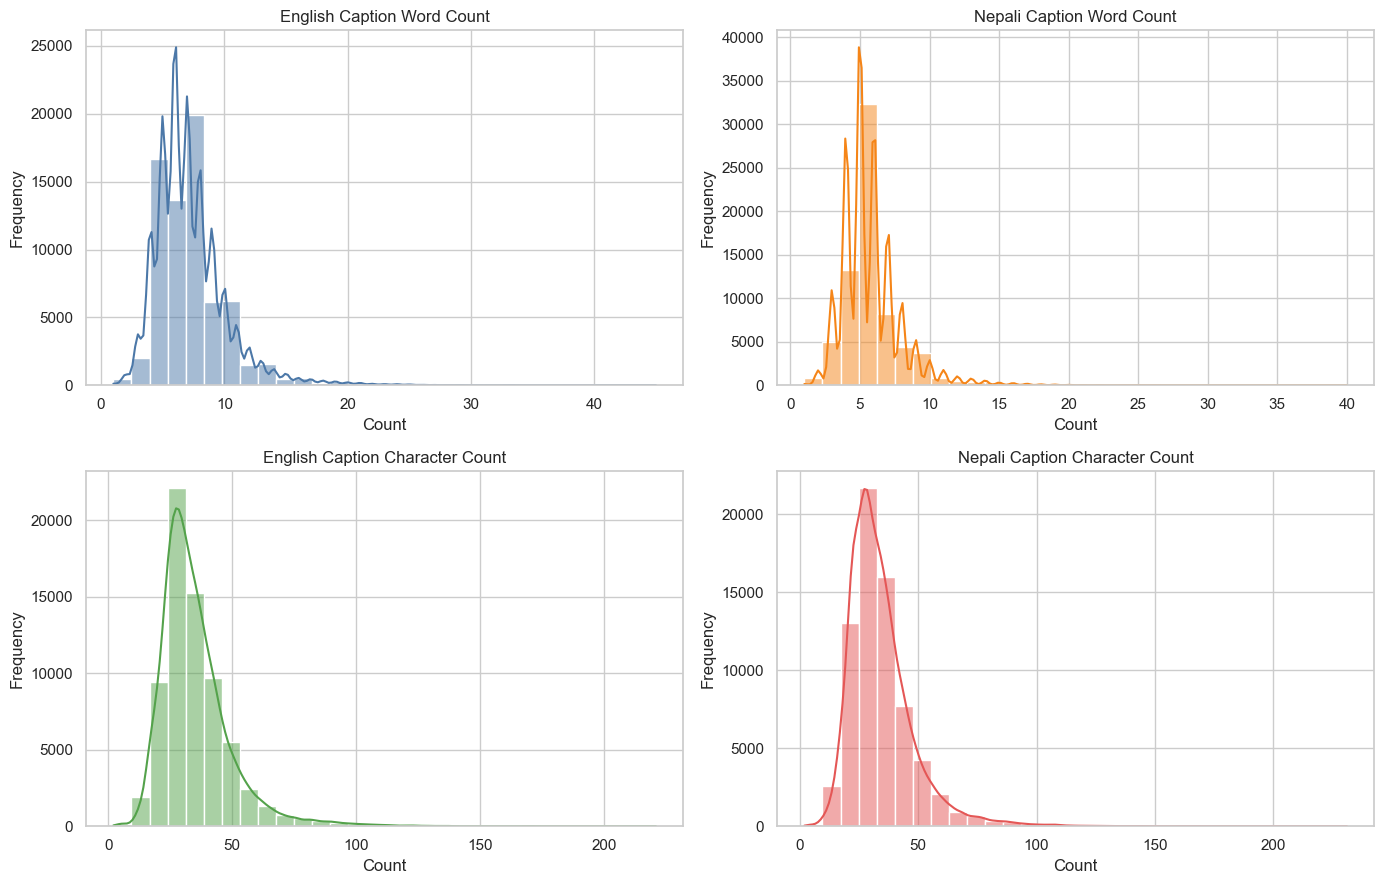

In [5]:
video_caption_counts = cleaned_df.groupby("video_id").size().sort_values(ascending=False)
display(video_caption_counts.describe().round(2).rename("captions_per_video"))
display(video_caption_counts.head(10).rename("captions_per_video"))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(cleaned_df["eng_word_count"], bins=30, kde=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("English Caption Word Count")

sns.histplot(cleaned_df["nep_word_count"], bins=30, kde=True, ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Nepali Caption Word Count")

sns.histplot(cleaned_df["eng_char_count"], bins=30, kde=True, ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("English Caption Character Count")

sns.histplot(cleaned_df["nep_char_count"], bins=30, kde=True, ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Nepali Caption Character Count")

for ax in axes.flat:
    ax.set_xlabel("Count")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [6]:
def english_tokens(text):
    return re.findall(r"[a-z']+", str(text).lower())

def nepali_tokens(text):
    return str(text).split()

english_counter = Counter()
nepali_counter = Counter()

for text in cleaned_df["eng_captions"]:
    english_counter.update(english_tokens(text))

for text in cleaned_df["nepali_captions"]:
    nepali_counter.update(nepali_tokens(text))

top_english_df = pd.DataFrame(english_counter.most_common(15), columns=["token", "count"])
top_nepali_df = pd.DataFrame(nepali_counter.most_common(15), columns=["token", "count"])

display(top_english_df)
display(top_nepali_df)

,token,count
0,a,77034
1,is,36234
2,the,26972
3,man,19116
4,in,8813
5,on,8708
6,woman,8261
7,of,6430
8,are,5969
9,and,5837


,token,count
0,छ,23147
1,एक,21014
2,एउटा,13831
3,मानिस,10357
4,महिला,8030
5,छन्,7801
6,एउटी,7568
7,छिन्,6016
8,र,4818
9,आफ्नो,4714


## Simple Word Pattern Notes

- The most common English words are short caption words like `a`, `is`, `the`, and `man`.
- The most common Nepali words are also caption-style words like `छ`, `एक`, `एउटा`, and `मानिस`.
- This means the dataset mostly contains direct visual descriptions.
- Because many word parts repeat, subword models should learn useful tokens from this cleaned text.

In [ ]:
nepali_corpus = cleaned_df["nepali_captions"].astype(str).tolist() 
#takes the nepali_captions column from the cleaned dataframe, 
#converts every value to string, and makes a Python list.
VOCAB_SIZE = 3000 #sets the maximum vocabulary size for each tokenizer.
SPECIAL_TOKENS = ["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]
# [UNK] for unknown words or pieces
# [PAD] for padding sequences to equal length
# [CLS] often used as a start or classification token
# [SEP] used to separate sequences
# [MASK] used in masked-language-model style tasks

bpe_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
# creates a BPE tokenizer
bpe_tokenizer.pre_tokenizer = Whitespace()
bpe_trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    min_frequency=2,
    special_tokens=SPECIAL_TOKENS,
    show_progress=False,
)
bpe_tokenizer.train_from_iterator(nepali_corpus, trainer=bpe_trainer)

wordpiece_tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))
wordpiece_tokenizer.pre_tokenizer = Whitespace()
wordpiece_trainer = WordPieceTrainer(
    vocab_size=VOCAB_SIZE,
    min_frequency=2,
    special_tokens=SPECIAL_TOKENS,
    show_progress=False,
)
wordpiece_tokenizer.train_from_iterator(nepali_corpus, trainer=wordpiece_trainer)

bpe_tokenizer.save(str(TOKENIZER_DIR / "nepali_bpe_tokenizer.json"))
wordpiece_tokenizer.save(str(TOKENIZER_DIR / "nepali_wordpiece_tokenizer.json"))

print("BPE vocab size:", bpe_tokenizer.get_vocab_size())
print("WordPiece vocab size:", wordpiece_tokenizer.get_vocab_size())
print("Saved files:")
print("-", TOKENIZER_DIR / "nepali_bpe_tokenizer.json")
print("-", TOKENIZER_DIR / "nepali_wordpiece_tokenizer.json")

BPE vocab size: 3000
WordPiece vocab size: 3000
Saved files:
- tokenizers\nepali_bpe_tokenizer.json
- tokenizers\nepali_wordpiece_tokenizer.json


In [8]:
sample_texts = [
    cleaned_df.loc[0, "nepali_captions"],
    cleaned_df.loc[1, "nepali_captions"],
    cleaned_df.loc[4, "nepali_captions"],
    cleaned_df["nepali_captions"].iloc[cleaned_df["nep_word_count"].idxmax()],
]

comparison_rows = []
for text in sample_texts:
    bpe_tokens = bpe_tokenizer.encode(text).tokens
    wp_tokens = wordpiece_tokenizer.encode(text).tokens
    comparison_rows.append(
        {
            "text": text,
            "bpe_tokens": bpe_tokens,
            "bpe_token_count": len(bpe_tokens),
            "wordpiece_tokens": wp_tokens,
            "wordpiece_token_count": len(wp_tokens),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

sample_for_stats = cleaned_df["nepali_captions"].sample(2000, random_state=42).tolist()
bpe_lengths = [len(bpe_tokenizer.encode(text).tokens) for text in sample_for_stats]
wordpiece_lengths = [len(wordpiece_tokenizer.encode(text).tokens) for text in sample_for_stats]

tokenizer_stats = pd.DataFrame(
    {
        "tokenizer": ["BPE", "WordPiece"],
        "avg_tokens_per_caption": [np.mean(bpe_lengths), np.mean(wordpiece_lengths)],
        "median_tokens_per_caption": [np.median(bpe_lengths), np.median(wordpiece_lengths)],
        "max_tokens_in_sample": [np.max(bpe_lengths), np.max(wordpiece_lengths)],
    }
).round(3)

display(tokenizer_stats)

,text,bpe_tokens,bpe_token_count,wordpiece_tokens,wordpiece_token_count
0,एउटा चिपमङ्कले खाइरहेको छ,"[एउटा, चिपमङ्कले, खाइरहेको, छ]",4,"[एउटा, चिपमङ्, ##कले, खाइरहेको, छ]",5
1,एउटा चिपमङ्कले बदाम खाइरहेको छ,"[एउटा, चिपमङ्कले, ब, दा, म, खाइरहेको, छ]",7,"[एउटा, चिपमङ्, ##कले, ब, ##दा, ##म, खाइरहेको, छ]",8
2,एउटा गिलहरीले पुरै बदाम खाइरहेको छ,"[एउटा, गिलहरी, ले, पु, रै, ब, दा, म, खाइरहेको, छ]",10,"[एउटा, गिलहरी, ##ले, पु, ##रै, ब, ##दा, ##म, खाइरहेको, छ]",10
3,मैले यो चलचित्र लगभग 20 वर्षमा हेरेको थिइनँ मेरो बाल्यकालको सबैभन्दा पुरानो सम्झनाहरू मध्ये एक यो चलचित्र हेरिरहेको ...,"[मै, ले, यो, चलचित्र, लग, भ, ग, 2, 0, वर्, ष, मा, हेर, ेको, थि, इन, ँ, मेरो, बाल, ्य, का, लको, सबैभन्दा, पु, रा, नो,...",78,"[म, ##ै, ##ले, यो, चलचित्र, लग, ##भ, ##ग, 2, ##0, वर्ष, ##मा, हेर, ##ेको, थ, ##ि, ##इ, ##न, ##ँ, म, ##ेर, ##ो, बाल, ...",91


,tokenizer,avg_tokens_per_caption,median_tokens_per_caption,max_tokens_in_sample
0,BPE,7.129,6.0,61
1,WordPiece,7.381,6.0,65


## Simple Tokenization Notes

- Both tokenizers learn useful subwords from the cleaned Nepali captions.
- BPE often keeps frequent words or word pieces together, so its token sequences are slightly shorter here.
- WordPiece often uses `##` for continuation pieces, so the split pattern is easier to inspect.
- In this notebook, BPE looks a little more compact, while WordPiece looks a little more explicit.
- Both can work, but BPE looks slightly more efficient on this cleaned dataset.